# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [ ]:
# Standard library
import inspect
import json
import os
import re
import warnings
import webbrowser

# Data
import numpy as np
import pandas as pd

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.dates as mdates

# Forecasting - StatsForecast / Nixtla
import statsforecast
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
from statsforecast.utils import ConformalIntervals

# Hierarchical Forecasting - Nixtla
import hierarchicalforecast
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.utils import aggregate

# Settings
warnings.filterwarnings("ignore")

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")
data.head(100)



,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0
...,...,...,...
95,1 Topping,2017-07-05,0.0
96,1 Topping,2017-07-06,0.0
97,1 Topping,2017-07-07,0.0
98,1 Topping,2017-07-08,0.0


Esto se hizo con la finalidad de revisar si hay datos faltantes para cada hora es importante saber que todos los sabores estuvieran

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


### Punto 1

In [28]:
conteo_productos = (
    data["Product"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False, sort=False)
)

print(conteo_productos.to_string())

Product
1 Topping                           183
1 Topping Staff                     183
1 Toppings St                       183
3 Topping                           183
3 Topping Staff                     183
Apricot                             183
Apricot ST                          183
Apricot Staff                       183
Asia Research Free Scoop            183
Banana Caramel  /                   183
Banana Caramel St                   183
Banana Staff                        183
Building Promotion                  183
Chai Tea                            183
Chai Tea Staff                      183
Chai Tea st                         183
Cherry Alm Staff                    183
Cherry Almond                       183
Cherry Almond Fudge st              183
Chocoate Cookies                    183
Chocolate                           183
Chocolate St                        183
Chocolate Staff                     183
Coffee                              183
Coffee  St                      

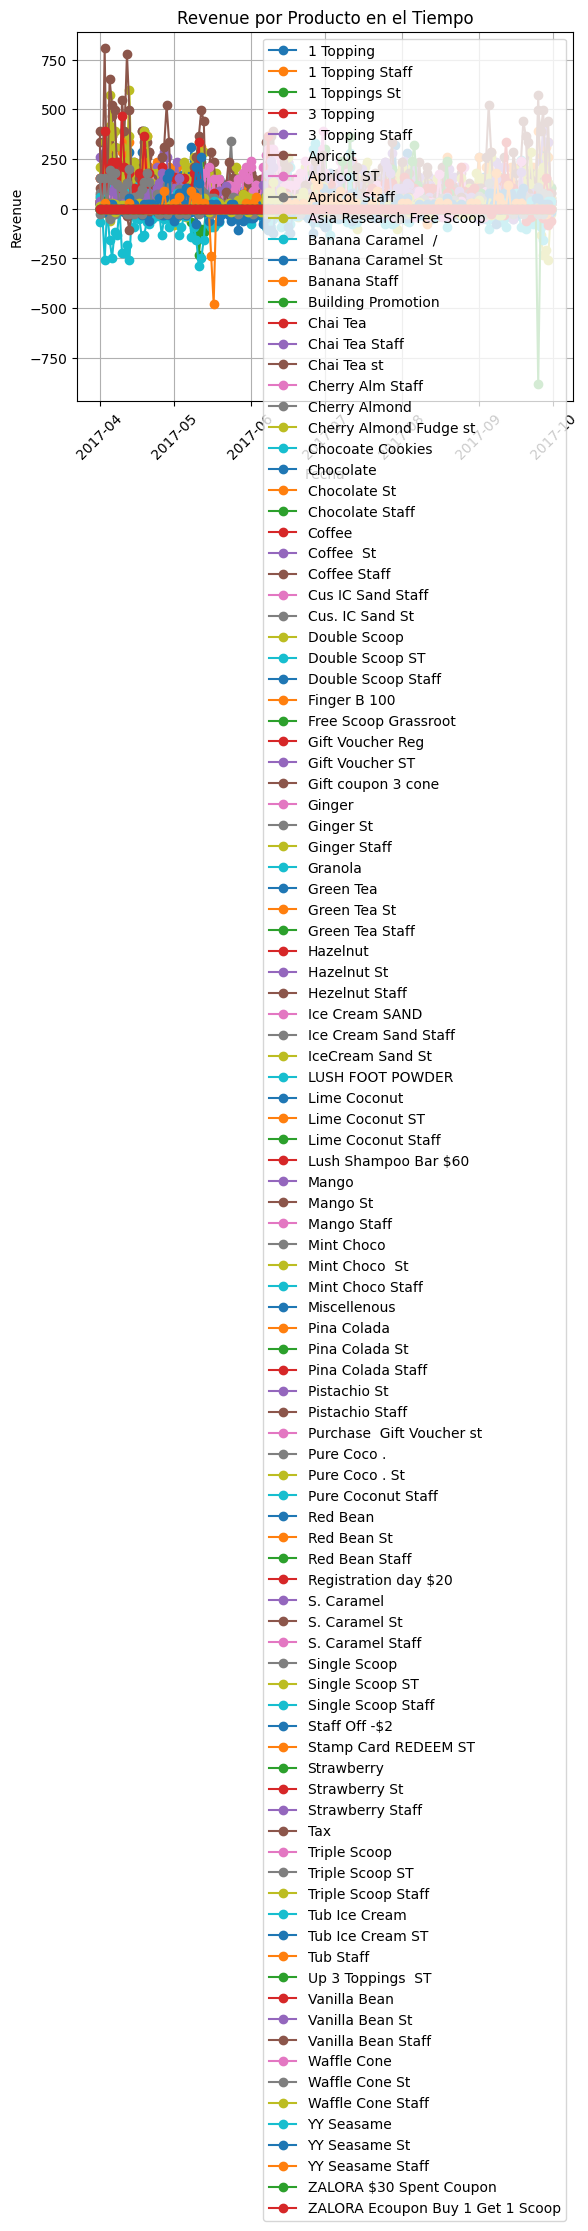

In [29]:
data["Date_clean"] = pd.to_datetime(data["Date_clean"])

for producto in data["Product"].unique():
    filtro = data[data["Product"] == producto]
    plt.plot(filtro["Date_clean"], filtro["Revenue"], marker="o", label=producto)

plt.title("Revenue por Producto en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import re
import json
import os
import webbrowser

# ============================================================
# 1. COPIA Y LIMPIEZA INICIAL
# ============================================================

df = data.copy()

df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Product"] = df["Product"].astype(str).str.strip()
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(subset=["Date_clean", "Product", "Revenue"])

df["Product_original"] = df["Product"]

# ============================================================
# 2. DICCIONARIO COMPLETO DE PRODUCTOS
# ============================================================

EXCEPCIONES_BASE = {
    "1 topping": "1 Topping",
    "1 toppings": "1 Topping",
    "3 topping": "3 Topping",
    "3 toppings": "3 Topping",
    "banana caramel": "Banana Caramel",
    "banana": "Banana Caramel",
    "apricot": "Apricot",
    "chai tea": "Chai Tea",
    "cherry almond": "Cherry Almond",
    "cherry almond fudge": "Cherry Almond Fudge",
    "chocoate cookies": "Chocolate Cookies",
    "chocolate": "Chocolate",
    "coffee": "Coffee",
    "cus ic sand": "Cus IC Sand",
    "cus. ic sand": "Cus IC Sand",
    "double scoop": "Double Scoop",
    "green tea": "Green Tea",
    "hazelnut": "Hazelnut",
    "hezelnut": "Hazelnut",
    "ice cream sand": "Ice Cream Sand",
    "icecream sand": "Ice Cream Sand",
    "lime coconut": "Lime Coconut",
    "mango": "Mango",
    "mint choco": "Mint Choco",
    "miscellenous": "Miscellenous",
    "pina colada": "Pina Colada",
    "pistachio": "Pistachio",
    "pure coco": "Pure Coconut",
    "pure coconut": "Pure Coconut",
    "red bean": "Red Bean",
    "s. caramel": "S. Caramel",
    "single scoop": "Single Scoop",
    "strawberry": "Strawberry",
    "triple scoop": "Triple Scoop",
    "tub": "Tub Ice Cream",
    "tub ice cream": "Tub Ice Cream",
    "up 3 toppings": "Up 3 Toppings",
    "vanilla bean": "Vanilla Bean",
    "waffle cone": "Waffle Cone",
    "yy seasame": "YY Seasame"
}

# ============================================================
# 3. FUNCIÓN PARA LIMPIAR PRODUCTO Y CATEGORÍA
# ============================================================

def limpiar_producto(prod):
    s = str(prod).strip()

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*/\s*$", "", s)
    s = re.sub(r"\s*\.\s*$", "", s)

    if re.search(r"\bstaff$", s, flags=re.IGNORECASE):
        categoria = "Staff"
        base = re.sub(r"\bstaff$", "", s, flags=re.IGNORECASE).strip()

    elif re.search(r"\bst$", s, flags=re.IGNORECASE):
        categoria = "Student"
        base = re.sub(r"\bst$", "", s, flags=re.IGNORECASE).strip()

    else:
        categoria = "Publico general"
        base = s.strip()

    base = re.sub(r"\s+", " ", base)
    base = re.sub(r"\s*/\s*$", "", base)
    base = re.sub(r"\s*\.\s*$", "", base).strip()

    clave = base.lower()
    base_final = EXCEPCIONES_BASE.get(clave, base)

    producto_mostrado = f"{base_final} - {categoria}"

    return pd.Series([base_final, categoria, producto_mostrado])

df[["Product_base", "Categoria", "Product_limpio"]] = df["Product"].apply(limpiar_producto)
df["Product"] = df["Product_limpio"]

# ============================================================
# 4. USAR TODOS LOS PRODUCTOS
# ============================================================

df_todos = df.copy()

# ============================================================
# 5. AGRUPAR POR SEMANA, PRODUCTO Y CATEGORÍA
# ============================================================

df_grouped = (
    df_todos
    .groupby([
        pd.Grouper(key="Date_clean", freq="W-SUN"),
        "Product_base",
        "Categoria"
    ], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Categoria", "Date_clean"])
)

df_grouped = df_grouped.rename(columns={"Date_clean": "Semana"})

# ============================================================
# 6. TOTAL SEMANAL POR PRODUCTO
# ============================================================

df_total_sabor = (
    df_grouped
    .groupby(["Semana", "Product_base"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Semana"])
)

df_total_sabor["Categoria"] = "Total categoria"

# ============================================================
# 7. TOTAL SEMANAL GENERAL DE TODOS LOS PRODUCTOS
# ============================================================

df_total_general = (
    df_grouped
    .groupby(["Semana"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Semana")
)

# ============================================================
# 8. DATAFRAME FINAL PARA PREDICCIÓN GENERAL
# ============================================================

df_final_agrupado = df_total_general.copy()
df_final_agrupado.columns = ["Semana", "Revenue_Total"]

print("Agrupación semanal completa: todos los productos")
display(df_final_agrupado)

# ============================================================
# 9. DATAFRAME SEMANAL DETALLADO POR PRODUCTO
# ============================================================

df_semanal_por_producto = df_total_sabor.copy()
df_semanal_por_producto = df_semanal_por_producto.rename(
    columns={"Product_base": "Producto", "Revenue": "Revenue_Total"}
)

print("Agrupación semanal por producto")
display(df_semanal_por_producto)

# ============================================================
# 10. GRÁFICO INTERACTIVO
# ============================================================

sabores = sorted(df_grouped["Product_base"].unique())
categorias_base = ["Publico general", "Student", "Staff"]

fig = go.Figure()
trace_map = {}

for idx, sabor in enumerate(sabores):
    trace_map[sabor] = {}

    for categoria in categorias_base:
        temp = df_grouped[
            (df_grouped["Product_base"] == sabor) &
            (df_grouped["Categoria"] == categoria)
        ].sort_values("Semana")

        fig.add_trace(
            go.Scatter(
                x=temp["Semana"],
                y=temp["Revenue"],
                mode="lines+markers",
                name=categoria,
                visible=(idx == 0)
            )
        )

        trace_map[sabor][categoria] = len(fig.data) - 1

    temp_total = df_total_sabor[
        df_total_sabor["Product_base"] == sabor
    ].sort_values("Semana")

    fig.add_trace(
        go.Scatter(
            x=temp_total["Semana"],
            y=temp_total["Revenue"],
            mode="lines+markers",
            name="Total producto",
            visible=False,
            line=dict(dash="dash")
        )
    )

    trace_map[sabor]["Total producto"] = len(fig.data) - 1

fig.add_trace(
    go.Scatter(
        x=df_total_general["Semana"],
        y=df_total_general["Revenue"],
        mode="lines+markers",
        name="Total general",
        visible=False,
        line=dict(width=4)
    )
)

global_trace_index = len(fig.data) - 1

titulo_inicial = (
    f"Revenue semanal de {sabores[0]} por categoría"
    if sabores
    else "Revenue semanal por categoría"
)

fig.update_layout(
    title=titulo_inicial,
    xaxis_title="Semana",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    width=1450,
    height=850,
    margin=dict(t=120, r=40, l=60, b=60),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

# ============================================================
# 11. EXPORTAR GRÁFICO A HTML
# ============================================================

grafico_html = pio.to_html(
    fig,
    full_html=False,
    include_plotlyjs="cdn",
    div_id="grafico_sabores"
)

options_html = "\n".join(
    [f'<option value="{sabor}">{sabor}</option>' for sabor in sabores]
)

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <title>Gráfico semanal de productos</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
        }}
        .barra-controles {{
            display: flex;
            gap: 12px;
            align-items: center;
            flex-wrap: wrap;
            margin-bottom: 16px;
        }}
        .barra-controles label {{
            font-weight: bold;
        }}
        .barra-controles select,
        .barra-controles button {{
            padding: 8px 12px;
            font-size: 14px;
            cursor: pointer;
        }}
    </style>
</head>
<body>

<div class="barra-controles">
    <label for="selectorSabor">Producto:</label>
    <select id="selectorSabor">
        {options_html}
    </select>

    <button id="btnTotalCategoria">Mostrar total producto</button>
    <button id="btnTotalGeneral">Mostrar total general</button>
</div>

{grafico_html}

<script>
    const sabores = {json.dumps(sabores, ensure_ascii=False)};
    const traceMap = {json.dumps(trace_map, ensure_ascii=False)};
    const globalTraceIndex = {global_trace_index};

    const gd = document.getElementById("grafico_sabores");
    const selector = document.getElementById("selectorSabor");
    const btnTotalCategoria = document.getElementById("btnTotalCategoria");
    const btnTotalGeneral = document.getElementById("btnTotalGeneral");

    let saborActual = sabores.length > 0 ? sabores[0] : null;
    let totalCategoriaVisible = false;
    let vistaTotalGeneral = false;

    function actualizarVista() {{
        const visibles = Array(gd.data.length).fill(false);

        if (vistaTotalGeneral) {{
            visibles[globalTraceIndex] = true;

            Plotly.restyle(gd, "visible", visibles);
            Plotly.relayout(gd, {{
                title: "Revenue semanal total general: todos los productos"
            }});

            selector.disabled = true;
            btnTotalCategoria.disabled = true;
            btnTotalGeneral.textContent = "Volver al detalle";
            return;
        }}

        visibles[traceMap[saborActual]["Publico general"]] = true;
        visibles[traceMap[saborActual]["Student"]] = true;
        visibles[traceMap[saborActual]["Staff"]] = true;

        if (totalCategoriaVisible) {{
            visibles[traceMap[saborActual]["Total producto"]] = true;
        }}

        Plotly.restyle(gd, "visible", visibles);

        Plotly.relayout(gd, {{
            title: totalCategoriaVisible
                ? `Revenue semanal de ${{saborActual}} por categoría + total producto`
                : `Revenue semanal de ${{saborActual}} por categoría`
        }});

        selector.disabled = false;
        btnTotalCategoria.disabled = false;

        btnTotalCategoria.textContent = totalCategoriaVisible
            ? "Ocultar total producto"
            : "Mostrar total producto";

        btnTotalGeneral.textContent = "Mostrar total general";
    }}

    selector.addEventListener("change", function() {{
        saborActual = this.value;
        vistaTotalGeneral = false;
        actualizarVista();
    }});

    btnTotalCategoria.addEventListener("click", function() {{
        if (vistaTotalGeneral) return;
        totalCategoriaVisible = !totalCategoriaVisible;
        actualizarVista();
    }});

    btnTotalGeneral.addEventListener("click", function() {{
        vistaTotalGeneral = !vistaTotalGeneral;
        actualizarVista();
    }});

    actualizarVista();
</script>

</body>
</html>
"""

nombre_archivo = "grafico_productos_semanal.html"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"Archivo generado: {nombre_archivo}")

webbrowser.open("file://" + os.path.abspath(nombre_archivo))

Agrupación semanal completa: todos los productos


,Semana,Revenue_Total
0,2017-04-02,2348.00000
1,2017-04-09,15125.00000
2,2017-04-16,11540.00000
3,2017-04-23,14016.99999
4,2017-04-30,11172.99998
5,2017-05-07,10163.00000
6,2017-05-14,11287.00000
7,2017-05-21,8191.99998
8,2017-05-28,7190.99998
9,2017-06-04,7377.99996


Agrupación semanal por producto


,Semana,Producto,Revenue_Total,Categoria
0,2017-04-02,1 Topping,0.0,Total categoria
51,2017-04-09,1 Topping,6.0,Total categoria
102,2017-04-16,1 Topping,21.0,Total categoria
153,2017-04-23,1 Topping,46.0,Total categoria
204,2017-04-30,1 Topping,20.0,Total categoria
...,...,...,...,...
1172,2017-09-03,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria
1223,2017-09-10,ZALORA Ecoupon Buy 1 Get 1 Scoop,-26.0,Total categoria
1274,2017-09-17,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria
1325,2017-09-24,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria


Archivo generado: grafico_productos_semanal.html


True

## 🗒️ Abrir grafico_sabores.html 
### El mas importante es   "Mint Choco" y "S. Caramel",

Este grafico es lra repesentacion visual del las ganacias totales por porducto vendido, agrupando las ganacias y los costos, ccon los botones se puede ver el costo total y los costos por categoria st (student), staff y publico generla

## Hallazgos observados

* No tiene sentido que **One Scoop**, **Dolce Scoop** y **Triple Scoop** aparezcan como **valores módulo**, porque eso invierte los datos a positivos y puede distorsionar el análisis.

* En **Stamp Card * se observan **pérdidas**.

* **Ice Cream Sand** presenta **valores nulos** desde el **3 de junio** hasta el **25 de junio**.

* **Avellana** muestra una **caída** desde el **20 de mayo** hasta el **13 de junio**.

* **Jengibre**, como se mencionaba en el texto por las creencias chinas, **sube** desde el **13 de mayo** hasta el **31 de mayo**; luego **vuelve a caer**; y entre el **12 de julio** y el **9 de agosto** **presenta otro incremento**.

* **Red Bean** tiene un **comportamiento similar al de productos calientes**, ya que entre el **30 de mayo** y el **21 de junio** se comporta de esa manera.

* **Pistacho** **sube** desde el **5 de junio** hasta el **10 de junio**.

* **Lime Coconut** **sube** desde el **10 de julio** hasta el **29 de julio**; allí presenta una **leve caída**; luego **vuelve a subir** el **10 de agosto**; alcanza su **pico el 19 de agosto**; y después **desciende** hasta el **28 de agosto**.

* **Coffee** **sube** desde el **8 de junio** hasta el **27 de junio** y presenta **valores nulos** desde el **27 de junio** hasta el **6 de julio**.



### Punto 2

### ✅ Identificación Modelo Base
Primero identificamos los productos que mas se venden 


In [31]:
top_productos = (data.groupby('Product')['Revenue'].sum().sort_values(ascending=False))
print(top_productos.head(10))

Product
S. Caramel St       25201.79338
Mint Choco  St      14861.04761
Mango St            14128.30953
Chocolate St        13906.33333
Pure Coco . St      13570.33333
Strawberry St       11541.50000
S. Caramel Staff    10226.21211
Chai Tea st          9952.83333
Hazelnut St          9824.66666
Green Tea St         9667.50000
Name: Revenue, dtype: float64


Ahora debemos agrupar los dos sabores que más se venden, para este caso sera Mint Choco y S. Caramel, agruparemos estos dos datos para realizar nuestra predicción más adelante.

In [32]:
# 1. Filtramos los dos sabores (incluyendo todas sus variantes de categoría)
sabores_top = ['S. Caramel', 'Mint Choco']
df_top2 = data[data['Product'].str.contains('|'.join(sabores_top), case=False, na=False)].copy()

# 2. Aseguramos formato fecha y agrupamos
df_top2['Date_clean'] = pd.to_datetime(df_top2['Date_clean'])
serie_top2 = df_top2.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)

# 3. Lo convertimos a un DataFrame limpio para que lo veas claro
df_final_agrupado = serie_top2.reset_index()
df_final_agrupado.columns = ['Semana', 'Revenue_Total']

print("Agrupación completada: S. Caramel + Mint Choco")

Agrupación completada: S. Caramel + Mint Choco


### 📊 Visualización de Datos


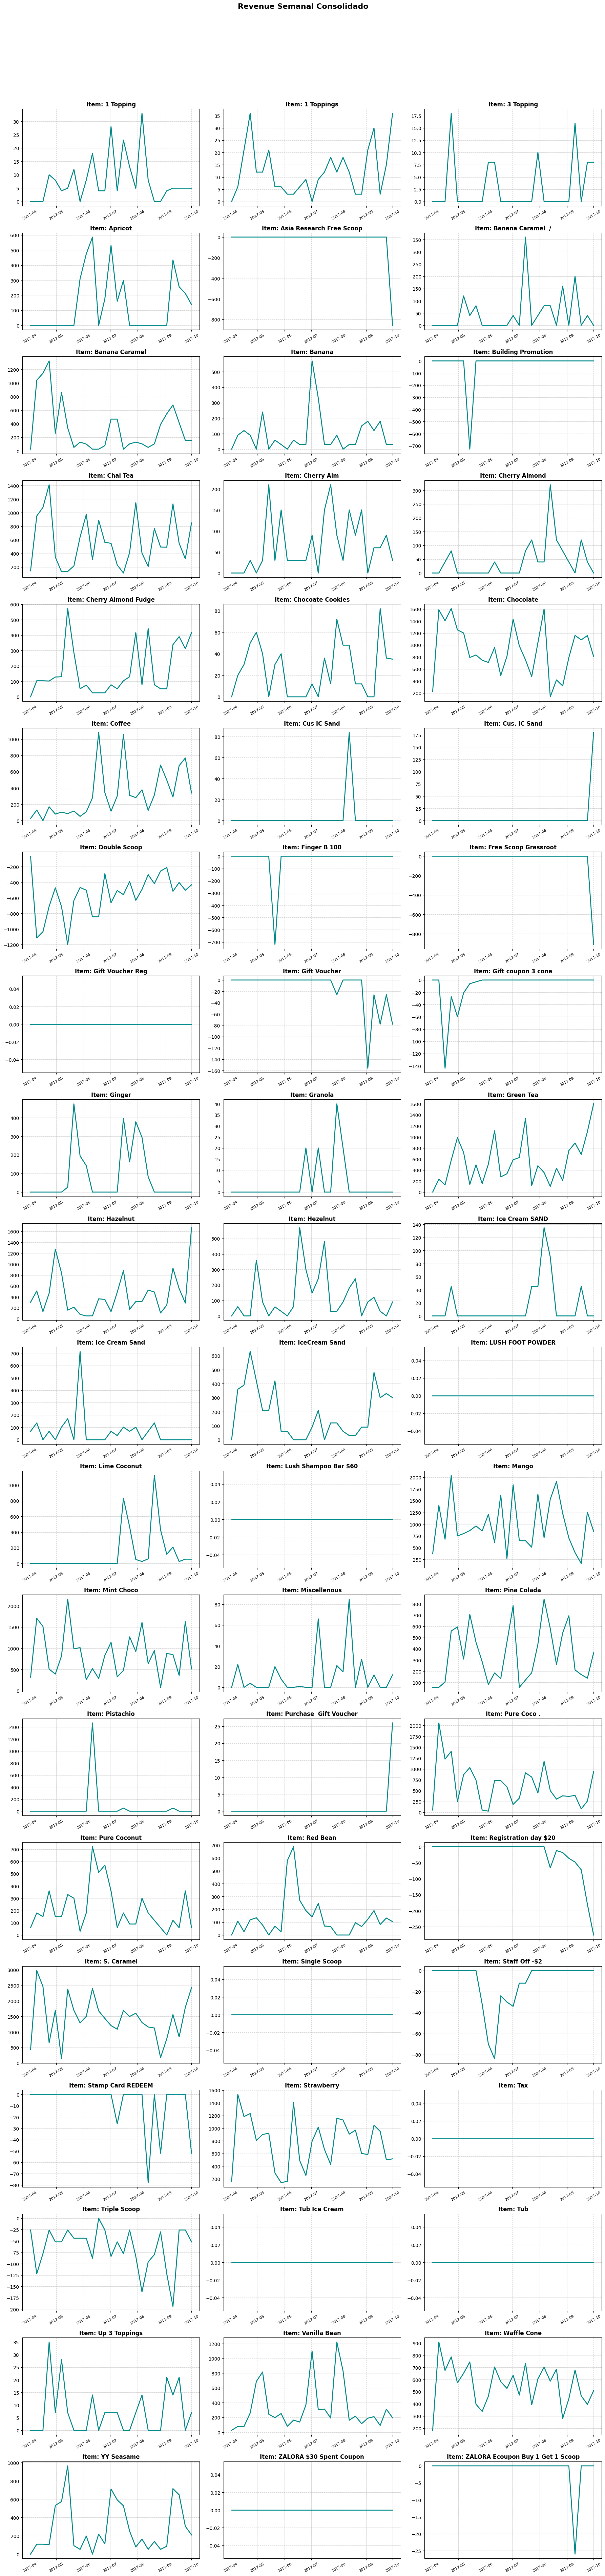

In [33]:
# 1. Creamos una copia para no dañar los nombres originales por si los necesitas luego
df_plot = data.copy()

# 2. Limpiamos los nombres de los productos quitando las categorías
# Reemplazamos "Staff", "St", "st", etc., por nada para que queden iguales
df_plot['Product'] = df_plot['Product'].str.replace(' Staff', '', case=False)\
                                       .str.replace(' St', '', case=False)\
                                       .str.replace(' st', '', case=False)\
                                       .str.replace(' Student', '', case=False)\
                                       .str.replace(' Tourists', '', case=False)\
                                       .str.strip()

# 3. Obtenemos los productos únicos (ahora ya agrupados por sabor)
productos_unicos = df_plot['Product'].unique()

# 4. Configurar la cuadrícula automática
cols = 3
rows = (len(productos_unicos) // cols) + (1 if len(productos_unicos) % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
fig.suptitle('Revenue Semanal Consolidado', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, producto in enumerate(productos_unicos):
    ax = axes[i]
    
    # Filtramos por el sabor ya limpio
    sub = df_plot[df_plot['Product'] == producto].copy()
    
    # Agrupamos por semana y sumamos el revenue de todas las categorías juntas
    serie = sub.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)
    
    ax.plot(serie.index, serie.values, color='darkcyan', linewidth=2)
    ax.set_title(f'Item: {producto}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', labelsize=8, rotation=30)

# Ocultar los cuadros que sobren
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 📈 Division train / test

In [34]:
# Consolidamos los productos más relevantes en un solo DataFrame
df_eval = pd.DataFrame()

for producto in productos_unicos:
    sub = df_plot[df_plot['Product'] == producto].copy()
    serie = sub.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)
    df_eval[producto] = serie

# División train / test
n_test = 4
train = df_eval.iloc[:-n_test]
test  = df_eval.iloc[-n_test:]

print("Total:", len(df_eval), "semanas")
print("Train:", len(train), "semanas")
print("Test:",  len(test),  "semanas")

Total: 27 semanas
Train: 23 semanas
Test: 4 semanas


### 📈 Predicciones 

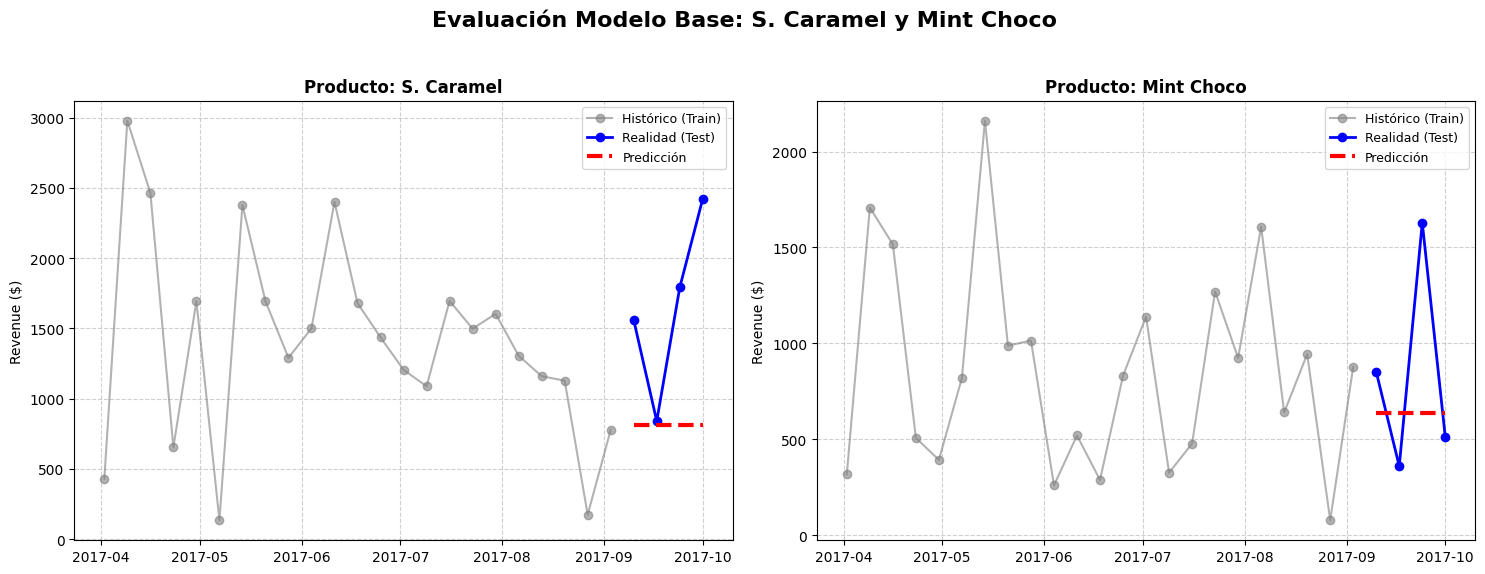

               MAE  MAPE (%)
S. Caramel  843.79     43.25
Mint Choco  402.33     46.73


In [ ]:
# Predicción Modelo Base (Media Móvil últimas 4 semanas)
forecast_base = train_agrupado.iloc[-n_test:].mean()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Evaluación Modelo Base: S. Caramel y Mint Choco', fontsize=16, fontweight='bold')

for i, sabor in enumerate(sabores_meta):
    ax = axes[i]

    ax.plot(train_agrupado.index, train_agrupado[sabor],
            label='Histórico (Train)', color='gray', marker='o', alpha=0.6)

    ax.plot(test_agrupado.index, test_agrupado[sabor],
            label='Realidad (Test)', color='blue', marker='o', linewidth=2)

    pred_valor = forecast_base[sabor]
    ax.hlines(y=pred_valor,
              xmin=test_agrupado.index[0],
              xmax=test_agrupado.index[-1],
              color='red', linestyle='--', linewidth=3,
              label=f'Predicción')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_title(f'Producto: {sabor}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Revenue ($)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# metricas
resultados = {}
for sabor in sabores_meta:
    
    real = test_agrupado[sabor]
    pred = [forecast_base[sabor]] * len(test_agrupado)
    
    mae = mean_absolute_error(real, pred)
    mape = mean_absolute_percentage_error(real, pred)
    
    resultados[sabor] = {
        'MAE': round(mae, 2),
        'MAPE (%)': round(mape*100, 2)
    }

df_resultados = pd.DataFrame(resultados).T
print(df_resultados)

De primera mano se eligieron estos dos productos ya que como podemos notar al principio de este notebook "se solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes", por eso hemos decidido elegir **S. Caramel** y **Mint Choco** ya que estos dos productos generan $25.201 y $14.861 de ganancia respectivamente. Ahora bien, como podemos notar en la predicción de nuestro modelo base con media movil, podemos ver que para:

- **S. Caramel** el modelo predice un valor constante de aprox. $810 semanales, mientras que la realidad varia entre $810 y $2400, el MAE de $843 y MAPE de 43.25% nos indican que captura el nivel promedio más no los picos de demanda

- **Choco Mint** el modelo predice un valor de aprox. $630 semanales, su comportamiento oscila entre los $370 y $1640, para este caso el MAE de $402 y MAPE del 47% reflejan la misma limitación, donde hay una alta variabilidad que el modelo aún no puede capturar


### 📈 Analisis de una serie 
En esta sección lo que haremos sera analizar la serie de tiempo del producto más significativo

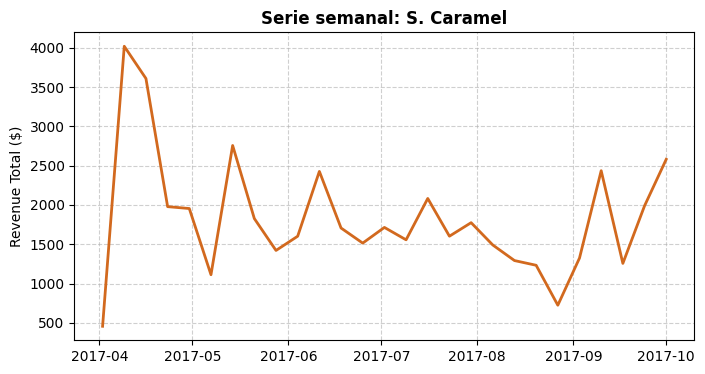

In [37]:
# Agrupamos todas las variantes de Caramel (St, Staff, etc.) en una sola serie
df_caramel = data[data['Product'].str.contains('Caramel', case=False, na=False)].copy()
serie_analizar = df_caramel.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)

# Gráfica de la serie agrupada
plt.figure(figsize=(8,4))
plt.plot(serie_analizar, color='chocolate', linewidth=2)
plt.title("Serie semanal: S. Caramel", fontweight='bold')
plt.ylabel("Revenue Total ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Hemos decidido ver como se ve la serie semanal agrupada de **S. Caramel** ya que es nuestro producto más relevante, como podemos notar hay una alta variabilidad con picos que llegan de $1000 hasta $4000, fuera de un par de meses con zonas estables, no podemos notar alguna evidencia en una tendencia o patron.

### 🔎 Conclusión Modelo Base 


En conclusión, el modelo base (media móvil) se ve un poco limitado ya que genera predicciones constantes que no logran capturar la tendencia o algun patron aparente en el revenue. Esto se puede ver en los altos errores obtenidos de acuerdo a las metricas obtenidas, así se evidencia que no logra capturar realmente esos cambios bruscos que tenemos. Sin embargo, esto no es un fallo del modelo sino por la manera en como funciona la media movil esta diseñada para "rondar" el promedio reciente, por lo que ante series ruidosas tendera a suavizar y aplanar la predicción que es lo que notamos en las predicciones anteriores sobre nuestros productos más relevantes.

### Punto 3

In [44]:
# ============================================================
# GRÁFICA: Real vs Ajustado (train) vs Forecast (test)
# AUTOCONTENIDO — solo necesita que existan en memoria:
#   Y_df, Y_train, Y_test, S_df, tags, fcst_rec_test, col_mint
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, SeasonalNaive, AutoTheta
import plotly.io as pio

pio.renderers.default = "browser"

SEASON = 4

# ============================================================
# PASO 1 — Regenerar cv_df si no existe
# ============================================================

if "cv_df" not in dir():
    print("cv_df no encontrado, generando cross-validation…")

    models_cv = [
        AutoARIMA(season_length=SEASON),
        AutoETS(season_length=SEASON),
        SeasonalNaive(season_length=SEASON),
        AutoTheta(season_length=SEASON),
    ]

    n_train    = Y_train["ds"].nunique()
    n_windows  = max(2, min(8, n_train - SEASON - 2))

    sf_cv = StatsForecast(
        models=models_cv, freq="W-SUN", n_jobs=-1,
        fallback_model=SeasonalNaive(season_length=SEASON),
    )

    cv_df = sf_cv.cross_validation(
        df=Y_train, h=1, n_windows=n_windows, step_size=1
    )
    cv_df["ds"] = pd.to_datetime(cv_df["ds"])

    # Columnas de modelos
    model_cols_cv = [
        c for c in cv_df.columns
        if c not in ("unique_id", "ds", "cutoff", "y")
        and "lo" not in c.lower() and "hi" not in c.lower()
    ]

    # MAPE in-sample por serie y modelo → elegir el mejor
    mape_rows = []
    for uid in cv_df["unique_id"].unique():
        sub  = cv_df[cv_df["unique_id"] == uid]
        real = sub["y"].values
        for mc in model_cols_cv:
            pred = sub[mc].values
            nz   = real != 0
            mape = (np.abs((real[nz]-pred[nz])/real[nz]).mean()*100
                    if nz.sum() > 0 else np.inf)
            mape_rows.append({"unique_id": uid, "model": mc, "mape": mape})

    best_df = (
        pd.DataFrame(mape_rows)
        .sort_values("mape")
        .groupby("unique_id", as_index=False)
        .first()
    )

    # Fitted value = predicción del mejor modelo para cada fila
    cv_df = cv_df.merge(best_df[["unique_id","model"]], on="unique_id", how="left")

    def pick_fitted(row):
        c = row["model"]
        return row[c] if c in row.index else np.nan

    cv_df["fitted_best"] = cv_df.apply(pick_fitted, axis=1)
    print(f"cv_df generado: {cv_df.shape}")
else:
    print("cv_df encontrado en memoria, usando directamente.")
    # Asegurar columna fitted_best
    if "fitted_best" not in cv_df.columns and "fitted_ensemble" in cv_df.columns:
        cv_df["fitted_best"] = cv_df["fitted_ensemble"]
    elif "fitted_best" not in cv_df.columns:
        model_cols_cv = [c for c in cv_df.columns
                         if c not in ("unique_id","ds","cutoff","y","model")
                         and "lo" not in c.lower() and "hi" not in c.lower()]
        cv_df["fitted_best"] = cv_df[model_cols_cv].mean(axis=1)

# ============================================================
# PASO 2 — Verificar col_mint
# ============================================================

if "col_mint" not in dir() or col_mint is None:
    mint_cols = [c for c in fcst_rec_test.columns
                 if "MinTrace" in c
                 and "lo" not in c.lower() and "hi" not in c.lower()]
    col_mint = mint_cols[0] if mint_cols else None
    print(f"col_mint detectado: {col_mint}")

if col_mint is None:
    raise ValueError("No se encontró columna MinTrace en fcst_rec_test. "
                     "Ejecuta primero el bloque de reconciliación.")

# ============================================================
# PASO 3 — Series a graficar
# ============================================================

all_ids   = Y_df["unique_id"].unique()
total_ids = [u for u in all_ids if str(u) == "Total"]
prod_ids  = [u for u in all_ids if str(u).count("/") == 1]

top_prods = (
    Y_df[Y_df["unique_id"].isin(prod_ids)]
    .groupby("unique_id")["y"].sum()
    .sort_values(ascending=False)
    .index[:4].tolist()
)

plot_ids = total_ids + top_prods
print(f"Series: {[str(u).split('/')[-1] for u in plot_ids]}")

# ============================================================
# PASO 4 — Figura
# ============================================================

n_cols_p = 2
n_rows_p = int(np.ceil(len(plot_ids) / n_cols_p))

titles = [str(u).split("/")[-1] if "/" in str(u) else str(u) for u in plot_ids]
while len(titles) < n_rows_p * n_cols_p:
    titles.append("")

C_REAL = "#0D47A1"
C_FIT  = "#29B6F6"
C_FCST = "#D32F2F"
C_CUT  = "rgba(0,0,0,0.28)"

fig = make_subplots(
    rows=n_rows_p, cols=n_cols_p,
    subplot_titles=titles,
    vertical_spacing=0.13,
    horizontal_spacing=0.09,
)

for idx, uid in enumerate(plot_ids):
    row  = idx // n_cols_p + 1
    col  = idx %  n_cols_p + 1
    show = idx == 0

    real_all  = Y_df[Y_df["unique_id"] == uid].sort_values("ds")
    fit_uid   = cv_df[cv_df["unique_id"] == uid].sort_values("ds")
    fcst_test = fcst_rec_test[fcst_rec_test["unique_id"] == uid].sort_values("ds")
    cut       = Y_train[Y_train["unique_id"] == uid]["ds"].max()

    if real_all.empty:
        continue

    # Real completo
    fig.add_trace(go.Scatter(
        x=real_all["ds"], y=real_all["y"],
        mode="lines+markers",
        line=dict(color=C_REAL, width=2.2),
        marker=dict(size=5),
        name="Real", showlegend=show, legendgroup="real",
    ), row=row, col=col)

    # Fitted (mejor modelo, solo train)
    if not fit_uid.empty and "fitted_best" in fit_uid.columns:
        fit_clean = fit_uid.dropna(subset=["fitted_best"])
        if not fit_clean.empty:
            fig.add_trace(go.Scatter(
                x=fit_clean["ds"], y=fit_clean["fitted_best"],
                mode="lines+markers",
                line=dict(color=C_FIT, width=2, dash="dash"),
                marker=dict(size=4, symbol="circle-open"),
                name="Ajustado (train)",
                showlegend=show, legendgroup="fitted",
            ), row=row, col=col)

    # Forecast test con puente
    if not fcst_test.empty and col_mint in fcst_test.columns:
        ultimo = real_all[real_all["ds"] <= cut]
        bx = ([ultimo.iloc[-1]["ds"]] if not ultimo.empty else []) + fcst_test["ds"].tolist()
        by = ([ultimo.iloc[-1]["y"]]  if not ultimo.empty else []) + fcst_test[col_mint].tolist()

        fig.add_trace(go.Scatter(
            x=bx, y=by,
            mode="lines+markers",
            line=dict(color=C_FCST, width=2.5, dash="dot"),
            marker=dict(size=8, symbol="diamond"),
            name="Forecast MinTrace (test)",
            showlegend=show, legendgroup="forecast",
        ), row=row, col=col)

    # Línea de corte
    fig.add_vline(
        x=cut, row=row, col=col,
        line=dict(color=C_CUT, width=1.5, dash="dash"),
    )

fig.update_layout(
    title=dict(
        text=("Real vs Ajustado (train) vs Forecast MinTrace (test)<br>"
              "<sup>Azul oscuro = real &nbsp;|&nbsp; "
              "Azul claro = fitted mejor modelo CV &nbsp;|&nbsp; "
              "Rojo = forecast test reconciliado</sup>"),
        font=dict(size=13), x=0.5,
    ),
    height=330 * n_rows_p + 120,
    width=1150,
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(orientation="h", y=1.05, x=0, font=dict(size=11),
                bgcolor="rgba(255,255,255,0.9)", bordercolor="#CCC", borderwidth=1),
    font=dict(family="Arial", size=10),
    margin=dict(t=140, b=70, l=70, r=30),
)
fig.update_xaxes(showgrid=True, gridcolor="#EBEBEB",
                 tickformat="%b %Y", tickangle=-30, title_text="Semana")
fig.update_yaxes(showgrid=True, gridcolor="#EBEBEB",
                 title_text="Revenue", rangemode="tozero")

fig.show(renderer="browser")
fig.write_html("real_vs_fitted_vs_forecast_test.html")
print("→ real_vs_fitted_vs_forecast_test.html")

# ============================================================
# PASO 5 — Tabla real vs predicho en test
# ============================================================

Y_test_r = Y_test.copy()
Y_test_r["ds"] = pd.to_datetime(Y_test_r["ds"])

resultado_local = Y_test_r.merge(
    fcst_rec_test[["unique_id", "ds", col_mint]],
    on=["unique_id", "ds"], how="inner",
)

tbl = (
    resultado_local[resultado_local["unique_id"].isin(plot_ids)]
    [["unique_id", "ds", "y", col_mint]].copy()
    .rename(columns={"unique_id": "Serie", "ds": "Semana",
                     "y": "Real", col_mint: "Forecast"})
)
tbl["Serie"]    = tbl["Serie"].astype(str).str.split("/").str[-1]
tbl["Error"]    = (tbl["Real"] - tbl["Forecast"]).round(0).astype(int)
tbl["MAPE (%)"] = (
    np.abs(tbl["Error"] / tbl["Real"].replace(0, np.nan)) * 100
).round(1)
tbl["Real"]     = tbl["Real"].round(0).astype(int)
tbl["Forecast"] = tbl["Forecast"].round(0).astype(int)

print("\nReal vs Forecast — semanas de test:")
display(tbl.sort_values(["Serie", "Semana"]).reset_index(drop=True))

cv_df no encontrado, generando cross-validation…
cv_df generado: (1248, 10)
Series: ['Total', 'S. Caramel', 'Mango', 'Chocolate', 'Mint Choco']
→ real_vs_fitted_vs_forecast_test.html

Real vs Forecast — semanas de test:


,Serie,Semana,Real,Forecast,Error,MAPE (%)
0,Chocolate,2017-09-10,1160,853,307,26.5
1,Chocolate,2017-09-17,1086,853,233,21.5
2,Chocolate,2017-09-24,1158,852,306,26.4
3,Chocolate,2017-10-01,808,853,-45,5.6
4,Mango,2017-09-10,396,1128,-733,185.3
5,Mango,2017-09-17,162,1023,-861,531.5
6,Mango,2017-09-24,1256,1067,189,15.0
7,Mango,2017-10-01,848,1048,-200,23.6
8,Mint Choco,2017-09-10,852,746,106,12.4
9,Mint Choco,2017-09-17,360,692,-332,92.2


In [42]:


# ============================================================
# 1. PREPARAR df_hier
# ============================================================

df_hier = df_grouped.copy()
df_hier["Total"] = "Total"

df_hier = df_hier.rename(columns={"Semana": "ds", "Revenue": "y"})[
    ["ds", "Total", "Product_base", "Categoria", "y"]
]

for col in ["Total", "Product_base", "Categoria"]:
    df_hier[col] = (
        df_hier[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("/", "-", regex=False)
        .str.replace("\\", "-", regex=False)
    )

df_hier["ds"] = pd.to_datetime(df_hier["ds"])

# ── Anclar todas las fechas al domingo de su semana ──────────
df_hier["ds"] = df_hier["ds"] + pd.to_timedelta(
    (6 - df_hier["ds"].dt.weekday) % 7, unit="D"
)

df_hier["y"] = pd.to_numeric(df_hier["y"], errors="coerce").fillna(0.0)
df_hier = df_hier.sort_values(
    ["Total", "Product_base", "Categoria", "ds"]
).reset_index(drop=True)


# ============================================================
# 2. AGREGACIÓN JERÁRQUICA
# ============================================================

spec = [
    ["Total"],
    ["Total", "Product_base"],
    ["Total", "Product_base", "Categoria"],
]

Y_df, S_df, tags = aggregate(df=df_hier, spec=spec)

Y_df["ds"] = pd.to_datetime(Y_df["ds"])
Y_df["y"] = pd.to_numeric(Y_df["y"], errors="coerce").fillna(0.0)
Y_df = Y_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

n_series = Y_df["unique_id"].nunique()
n_fechas = Y_df["ds"].nunique()

print(f"Series jerárquicas: {n_series} | Semanas totales: {n_fechas}")
for level, ids in tags.items():
    print(f"  {level}: {len(ids)} series")


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

h = 4
fechas = np.sort(Y_df["ds"].unique())

if len(fechas) <= h:
    raise ValueError("No hay suficientes semanas para separar train/test.")

cutoff = fechas[-h]

Y_train = Y_df[Y_df["ds"] < cutoff].copy()
Y_test  = Y_df[Y_df["ds"] >= cutoff].copy()

print(f"\nTrain: {Y_train['ds'].min().date()} → {Y_train['ds'].max().date()} "
      f"({Y_train['ds'].nunique()} semanas)")
print(f"Test : {Y_test['ds'].min().date()} → {Y_test['ds'].max().date()} "
      f"({Y_test['ds'].nunique()} semanas)")


# ============================================================
# 4. MODELOS BASE: Ensemble AutoARIMA + AutoETS + AutoTheta
#    season_length=4 (trimestral corto) + alias sin / para ids
# ============================================================

models = [
    AutoARIMA(season_length=4),
    AutoETS(season_length=4),
    AutoTheta(season_length=4),
]

sf = StatsForecast(
    models=models,
    freq="W-SUN",
    n_jobs=-1,
    fallback_model=AutoARIMA(season_length=1),
)

Y_hat_train = sf.forecast(df=Y_train, h=h)
print("\nForecast base (ensemble) sobre train:", Y_hat_train.shape)
print("Columnas:", Y_hat_train.columns.tolist())


# ============================================================
# 5. RECONCILIACIÓN JERÁRQUICA
#    BottomUp + MinTrace(wls_struct)
#
#    Nota: wls_var requiere fitted values in-sample (predcciones
#    dentro del train), que StatsForecast no retorna por defecto.
#    wls_struct solo necesita la matriz S y sigue siendo más
#    agresivo que ols porque pondera por estructura jerárquica
#    en lugar de aplanar uniformemente los residuos.
# ============================================================

hrec_eval = HierarchicalReconciliation(
    reconcilers=[
        BottomUp(),
        MinTrace(method="wls_struct"),  # no requiere fitted values
    ]
)

sig = inspect.signature(hrec_eval.reconcile)
kw  = "S_df" if "S_df" in sig.parameters else "S"

fcst_rec_test = hrec_eval.reconcile(
    Y_hat_df=Y_hat_train,
    Y_df=Y_train,
    **{kw: S_df},
    tags=tags,
)

if "unique_id" not in fcst_rec_test.columns:
    fcst_rec_test = fcst_rec_test.reset_index()

fcst_rec_test["ds"] = pd.to_datetime(fcst_rec_test["ds"])


def _pred_cols(df, keyword):
    return [
        c for c in df.columns
        if keyword in c
        and "lo" not in c.lower()
        and "hi" not in c.lower()
    ]


cols_bu   = _pred_cols(fcst_rec_test, "BottomUp")
cols_mint = _pred_cols(fcst_rec_test, "MinTrace")
cols_base = _pred_cols(fcst_rec_test, "AutoARIMA")

col_bu   = cols_bu[0]   if cols_bu   else None
col_mint = cols_mint[0] if cols_mint else None
col_base = cols_base[0] if cols_base else None

print("\nColumnas forecast reconciliado:", fcst_rec_test.columns.tolist())
print(f"  Base     : {col_base}")
print(f"  BottomUp : {col_bu}")
print(f"  MinTrace : {col_mint}")


# ============================================================
# 6. MÉTRICAS MAE / RMSE / MAPE
# ============================================================

Y_test_r = Y_test.copy()
Y_test_r["ds"] = pd.to_datetime(Y_test_r["ds"])

cols_pred = [c for c in [col_base, col_bu, col_mint] if c]

if not cols_pred:
    raise ValueError("No se encontraron columnas de predicción.")

resultado = Y_test_r.merge(
    fcst_rec_test[["unique_id", "ds"] + cols_pred],
    on=["unique_id", "ds"],
    how="inner",
)
print(f"\nFilas en resultado real ∩ predicho: {len(resultado)}")


def calc_metricas(df, col_pred):
    registros = []
    for uid in df["unique_id"].unique():
        mask = df["unique_id"] == uid
        real = df.loc[mask, "y"].astype(float).values
        pred = df.loc[mask, col_pred].astype(float).values
        nz   = real != 0

        mae  = float(np.abs(real - pred).mean())
        rmse = float(np.sqrt(((real - pred) ** 2).mean()))
        mape = float(np.abs((real[nz] - pred[nz]) / real[nz]).mean() * 100) \
               if nz.sum() > 0 else np.nan

        registros.append({
            "unique_id": uid,
            "MAE":      round(mae,  2),
            "RMSE":     round(rmse, 2),
            "MAPE (%)": round(mape, 2) if not np.isnan(mape) else np.nan,
        })

    df_m = pd.DataFrame(registros)

    def nivel(uid):
        uid = str(uid)
        if uid == "Total":   return "Total"
        if uid.count("/") == 1: return "Producto"
        return "Categoria"

    df_m["Nivel"] = df_m["unique_id"].apply(nivel)
    df_m["Serie"] = df_m["unique_id"].astype(str).str.split("/").str[-1]

    return (
        df_m[["Nivel", "Serie", "MAE", "RMSE", "MAPE (%)"]]
        .sort_values(["Nivel", "MAPE (%)"], na_position="last")
        .reset_index(drop=True)
    )


m_base = m_bu = m_mint = None

print("\n" + "=" * 60)
print("MÉTRICAS – BASE AutoARIMA SIN RECONCILIAR")
print("=" * 60)
if col_base:
    m_base = calc_metricas(resultado, col_base)
    display(m_base)

print("\n" + "=" * 60)
print("MÉTRICAS – BOTTOM-UP RECONCILIADO")
print("=" * 60)
if col_bu:
    m_bu = calc_metricas(resultado, col_bu)
    display(m_bu)

print("\n" + "=" * 60)
print("MÉTRICAS – MINTRACE wls_var RECONCILIADO")
print("=" * 60)
if col_mint:
    m_mint = calc_metricas(resultado, col_mint)
    display(m_mint)


# ============================================================
# 7. RESUMEN COMPARATIVO
# ============================================================

print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO – MAPE PROMEDIO POR NIVEL Y MODELO")
print("=" * 60)

resumen_rows = []
for nombre, m_df in [("AutoARIMA Base", m_base), ("BottomUp", m_bu), ("MinTrace wls_struct", m_mint)]:
    if m_df is None:
        continue
    for nivel in ["Total", "Producto", "Categoria"]:
        sub = m_df[m_df["Nivel"] == nivel]["MAPE (%)"].dropna()
        resumen_rows.append({
            "Modelo": nombre,
            "Nivel": nivel,
            "MAPE promedio (%)": round(sub.mean(), 2) if len(sub) > 0 else np.nan,
            "N series": len(sub),
        })

df_resumen = pd.DataFrame(resumen_rows)
display(df_resumen.pivot_table(
    index="Modelo", columns="Nivel",
    values="MAPE promedio (%)", aggfunc="first",
))


# ============================================================
# 8. GRÁFICA MAPE POR NIVEL Y MODELO
# ============================================================

niveles = ["Total", "Producto", "Categoria"]
modelos, mape_data = [], {}

for nombre, m_df in [("AutoARIMA Base", m_base), ("BottomUp", m_bu), ("MinTrace wls_struct", m_mint)]:
    if m_df is None:
        continue
    modelos.append(nombre)
    mape_data[nombre] = {
        niv: m_df[m_df["Nivel"] == niv]["MAPE (%)"].dropna().mean()
        for niv in niveles
    }

colors = ["#2979FF", "#FF5252", "#00C853"]
fig8 = go.Figure()

for nombre, color in zip(modelos, colors):
    vals = [mape_data[nombre].get(niv, np.nan) for niv in niveles]
    fig8.add_trace(go.Bar(
        name=nombre, x=niveles, y=vals,
        marker_color=color, opacity=0.85,
        text=[f"{v:.1f}%" if v is not None and not pd.isna(v) else "" for v in vals],
        textposition="outside",
    ))

fig8.update_layout(
    title=dict(text="MAPE promedio por nivel jerárquico y método de reconciliación",
               font=dict(size=15), x=0.5),
    barmode="group",
    xaxis_title="Nivel jerárquico",
    yaxis_title="MAPE promedio (%)",
    yaxis=dict(rangemode="tozero", gridcolor="#E5E5E5"),
    plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(orientation="h", y=1.08, x=0),
    font=dict(family="Arial", size=11),
    height=450, width=850, margin=dict(t=100, b=60),
)
fig8.show(renderer="browser")
fig8.write_html("mape_jerarquico.html")
print("Gráfica guardada → mape_jerarquico.html")


# ============================================================
# 9. FORECAST FINAL CON INTERVALOS (sobre Y_df completo)
# ============================================================

sf_final = StatsForecast(
    models=models,
    freq="W-SUN",
    n_jobs=-1,
    fallback_model=AutoARIMA(season_length=1),
)

try:
    Y_hat_final = sf_final.forecast(
        df=Y_df,
        h=h,
        prediction_intervals=ConformalIntervals(h=h, n_windows=2),
        level=[90],
    )
    tiene_intervalos = True
except Exception as e:
    print(f"ConformalIntervals no disponible: {e}")
    Y_hat_final = sf_final.forecast(df=Y_df, h=h)
    tiene_intervalos = False


# ============================================================
# 10. RECONCILIACIÓN FINAL MinTrace(wls_var)
# ============================================================

hrec_ci = HierarchicalReconciliation(reconcilers=[MinTrace(method="wls_struct")])

sig2 = inspect.signature(hrec_ci.reconcile)
kw2  = "S_df" if "S_df" in sig2.parameters else "S"

fcst_ci = hrec_ci.reconcile(
    Y_hat_df=Y_hat_final,
    Y_df=Y_df,
    **{kw2: S_df},
    tags=tags,
)

if "unique_id" not in fcst_ci.columns:
    fcst_ci = fcst_ci.reset_index()

fcst_ci["ds"] = pd.to_datetime(fcst_ci["ds"])

print("Columnas forecast final:", fcst_ci.columns.tolist())

cols_fc = _pred_cols(fcst_ci, "MinTrace")
if cols_fc:
    col_fc = cols_fc[0]
elif "AutoARIMA" in fcst_ci.columns:
    col_fc = "AutoARIMA"
else:
    raise ValueError("No se encontró columna válida de forecast final.")


def _pick(cols, lvl=90):
    if not cols: return None
    scored = [(abs(int(n) - lvl), c) for c in cols for n in re.findall(r"\d+", c)]
    return min(scored, key=lambda x: x[0])[1] if scored else cols[0]

col_lo = col_hi = None
if tiene_intervalos:
    lo_cands = [c for c in fcst_ci.columns if "lo" in c.lower() and "MinTrace" in c]
    hi_cands = [c for c in fcst_ci.columns if "hi" in c.lower() and "MinTrace" in c]
    if not lo_cands: lo_cands = [c for c in fcst_ci.columns if "lo" in c.lower()]
    if not hi_cands: hi_cands = [c for c in fcst_ci.columns if "hi" in c.lower()]
    col_lo = _pick(lo_cands)
    col_hi = _pick(hi_cands)

print(f"Forecast: {col_fc} | Lo: {col_lo} | Hi: {col_hi}")


# ============================================================
# 11. GRÁFICA FORECAST FINAL
# ============================================================

all_ids  = Y_df["unique_id"].unique()
total_ids = [u for u in all_ids if str(u) == "Total"]
prod_ids  = [u for u in all_ids if str(u).count("/") == 1]

top_prods = (
    Y_df[Y_df["unique_id"].isin(prod_ids)]
    .groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .index[:4]
    .tolist()
)

plot_ids = total_ids + top_prods
n_plots  = len(plot_ids)
n_cols   = 2
n_rows   = int(np.ceil(n_plots / n_cols))

subplot_titles = [
    str(uid).split("/")[-1] if "/" in str(uid) else str(uid)
    for uid in plot_ids
]
while len(subplot_titles) < n_rows * n_cols:
    subplot_titles.append("")

BANDA = "rgba(255, 82, 82, 0.15)"

fig10 = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=subplot_titles,
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

for idx, uid in enumerate(plot_ids):
    row = idx // n_cols + 1
    col = idx %  n_cols + 1
    show = idx == 0

    hist = Y_df[Y_df["unique_id"] == uid].sort_values("ds")
    fut  = fcst_ci[fcst_ci["unique_id"] == uid].sort_values("ds")

    if hist.empty or fut.empty:
        continue

    cutoff_hist = hist["ds"].max()

    # Banda de confianza 90 %
    if col_lo and col_hi and col_lo in fut.columns and col_hi in fut.columns:
        fig10.add_trace(go.Scatter(
            x=pd.concat([fut["ds"], fut["ds"].iloc[::-1]]),
            y=pd.concat([fut[col_hi], fut[col_lo].iloc[::-1]]),
            fill="toself", fillcolor=BANDA,
            line=dict(color="rgba(0,0,0,0)"),
            name="IC 90%", showlegend=show, legendgroup="banda",
            hoverinfo="skip",
        ), row=row, col=col)

    # Histórico
    fig10.add_trace(go.Scatter(
        x=hist["ds"], y=hist["y"],
        mode="lines+markers",
        line=dict(color="#2979FF", width=1.8),
        marker=dict(size=4),
        name="Histórico", showlegend=show, legendgroup="historico",
    ), row=row, col=col)

    # Forecast
    fig10.add_trace(go.Scatter(
        x=fut["ds"], y=fut[col_fc],
        mode="lines+markers",
        line=dict(color="#FF5252", width=2.5, dash="dot"),
        marker=dict(size=7, symbol="diamond"),
        name="Forecast MinTrace",
        showlegend=show, legendgroup="forecast",
    ), row=row, col=col)

    # Línea de corte
    fig10.add_vline(
        x=cutoff_hist, row=row, col=col,
        line=dict(color="rgba(0,0,0,0.45)", width=1.2, dash="dot"),
    )

fig10.update_layout(
    title=dict(
        text="Forecast Jerárquico MinTrace(wls_struct) – 4 semanas adelante (domingos)",
        font=dict(size=15), x=0.5,
    ),
    height=320 * n_rows + 80, width=1100,
    plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(orientation="h", y=1.02, x=0, font=dict(size=11)),
    font=dict(family="Arial", size=10),
    margin=dict(t=100, b=60, l=60, r=30),
)

fig10.update_xaxes(
    showgrid=True, gridcolor="#E5E5E5",
    tickformat="%b %Y", tickangle=-30,
    title_text="Semana (domingo)",
)
fig10.update_yaxes(
    showgrid=True, gridcolor="#E5E5E5",
    title_text="Revenue", rangemode="tozero",
)

fig10.show(renderer="browser")
fig10.write_html("forecast_jerarquico_final.html")
print("Gráfica guardada → forecast_jerarquico_final.html")


# ============================================================
# 12. TABLA RESUMEN DEL FORECAST FINAL (domingos)
# ============================================================

resumen_forecast = (
    fcst_ci[fcst_ci["unique_id"].isin(plot_ids)][
        ["unique_id", "ds", col_fc]
        + ([col_lo, col_hi] if col_lo and col_hi else [])
    ]
    .rename(columns={
        "unique_id": "Serie",
        "ds":        "Semana (domingo)",
        col_fc:      "Forecast",
        **({col_lo: "IC 90% Lo", col_hi: "IC 90% Hi"} if col_lo and col_hi else {}),
    })
    .sort_values(["Serie", "Semana (domingo)"])
    .reset_index(drop=True)
)

resumen_forecast["Forecast"] = resumen_forecast["Forecast"].round(0).astype(int)

print("\nForecast final – próximas 4 semanas (domingos):")
display(resumen_forecast)

Series jerárquicas: 156 | Semanas totales: 27
  Total: 1 series
  Total/Product_base: 51 series
  Total/Product_base/Categoria: 104 series

Train: 2017-04-02 → 2017-09-03 (23 semanas)
Test : 2017-09-10 → 2017-10-01 (4 semanas)

Forecast base (ensemble) sobre train: (624, 5)
Columnas: ['unique_id', 'ds', 'AutoARIMA', 'AutoETS', 'AutoTheta']

Columnas forecast reconciliado: ['unique_id', 'ds', 'AutoARIMA', 'AutoETS', 'AutoTheta', 'AutoARIMA/BottomUp', 'AutoETS/BottomUp', 'AutoTheta/BottomUp', 'AutoARIMA/MinTrace_method-wls_struct', 'AutoETS/MinTrace_method-wls_struct', 'AutoTheta/MinTrace_method-wls_struct']
  Base     : AutoARIMA
  BottomUp : AutoARIMA/BottomUp
  MinTrace : AutoARIMA/MinTrace_method-wls_struct

Filas en resultado real ∩ predicho: 624

MÉTRICAS – BASE AutoARIMA SIN RECONCILIAR


,Nivel,Serie,MAE,RMSE,MAPE (%)
0,Categoria,Publico general,6.00,8.27,2.54
1,Categoria,Staff,12.56,14.01,12.04
2,Categoria,Publico general,34.13,42.21,24.28
3,Categoria,Student,33.19,40.62,34.57
4,Categoria,Student,90.84,99.99,37.84
...,...,...,...,...,...
151,Producto,Staff Off -$2,0.00,0.00,NaN
152,Producto,Tax,0.00,0.00,NaN
153,Producto,Tub Ice Cream,0.00,0.00,NaN
154,Producto,ZALORA $30 Spent Coupon,0.00,0.00,NaN



MÉTRICAS – BOTTOM-UP RECONCILIADO


,Nivel,Serie,MAE,RMSE,MAPE (%)
0,Categoria,Publico general,6.00,8.27,2.54
1,Categoria,Staff,12.56,14.01,12.04
2,Categoria,Publico general,34.13,42.21,24.28
3,Categoria,Student,33.19,40.62,34.57
4,Categoria,Student,90.84,99.99,37.84
...,...,...,...,...,...
151,Producto,Staff Off -$2,0.00,0.00,NaN
152,Producto,Tax,0.00,0.00,NaN
153,Producto,Tub Ice Cream,0.00,0.00,NaN
154,Producto,ZALORA $30 Spent Coupon,0.00,0.00,NaN



MÉTRICAS – MINTRACE wls_var RECONCILIADO


,Nivel,Serie,MAE,RMSE,MAPE (%)
0,Categoria,Publico general,5.91,8.22,1.53
1,Categoria,Staff,9.24,15.19,7.67
2,Categoria,Publico general,16.19,19.45,13.44
3,Categoria,Staff,15.91,18.02,15.21
4,Categoria,Staff,90.21,132.21,26.90
...,...,...,...,...,...
151,Producto,Staff Off -$2,0.11,0.15,NaN
152,Producto,Tax,0.11,0.15,NaN
153,Producto,Tub Ice Cream,0.32,0.44,NaN
154,Producto,ZALORA $30 Spent Coupon,0.11,0.15,NaN



RESUMEN COMPARATIVO – MAPE PROMEDIO POR NIVEL Y MODELO


Nivel,Categoria,Producto,Total
Modelo,,,
AutoARIMA Base,97.78,89.58,13.46
BottomUp,97.78,79.01,17.20
MinTrace wls_struct,101.88,83.99,13.50


Gráfica guardada → mape_jerarquico.html
Columnas forecast final: ['unique_id', 'ds', 'AutoARIMA', 'AutoARIMA-lo-90', 'AutoARIMA-hi-90', 'AutoETS', 'AutoETS-lo-90', 'AutoETS-hi-90', 'AutoTheta', 'AutoTheta-lo-90', 'AutoTheta-hi-90', 'AutoARIMA/MinTrace_method-wls_struct', 'AutoETS/MinTrace_method-wls_struct', 'AutoTheta/MinTrace_method-wls_struct']
Forecast: AutoARIMA/MinTrace_method-wls_struct | Lo: AutoARIMA-lo-90 | Hi: AutoARIMA-hi-90
Gráfica guardada → forecast_jerarquico_final.html

Forecast final – próximas 4 semanas (domingos):


,Serie,Semana (domingo),Forecast,IC 90% Lo,IC 90% Hi
0,Total,2017-10-08,10196,7594.772410,12692.412764
1,Total,2017-10-15,9756,9071.062730,11216.122444
2,Total,2017-10-22,10137,6767.055295,13520.129880
3,Total,2017-10-29,9716,8274.955295,12012.229880
4,Total/Chocolate,2017-10-08,900,147.734591,1687.040030
5,Total/Chocolate,2017-10-15,910,398.534591,1436.240030
6,Total/Chocolate,2017-10-22,907,302.734591,1532.040030
7,Total/Chocolate,2017-10-29,914,730.693843,1104.080779
8,Total/Mango,2017-10-08,1090,507.829071,1972.746813
9,Total/Mango,2017-10-15,837,-185.776569,1631.059213


### Evaluación del pronóstico (MAE y RMSE) para los últimos 28 días de septiembre

In [40]:
import pandas as pd
import inspect
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming df_hier, spec, StatsForecast, AutoARIMA, HierarchicalReconciliation, BottomUp, MinTrace are available from previous cells.

# Define the split date: last 28 days of September means from 2017-09-03 to 2017-09-30
split_date = pd.to_datetime('2017-09-03')

# Split df_hier into train and test based on date
df_hier_train_raw = df_hier[df_hier['ds'] < split_date].copy()
df_hier_test_actual_raw = df_hier[df_hier['ds'] >= split_date].copy()

# Aggregate for the training data to get Y_train, S_train, tags_train
Y_train, S_train, tags_train = aggregate(df=df_hier_train_raw, spec=spec)
Y_train["ds"] = pd.to_datetime(Y_train["ds"])
Y_train["y"] = pd.to_numeric(Y_train["y"], errors="coerce").fillna(0.0)
Y_train = Y_train.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Remove the 'index' column if it was inadvertently created during aggregation or reset_index
# This line is added based on previous errors encountered where 'index' was treated as an exogenous feature
if 'index' in Y_train.columns:
    Y_train = Y_train.drop(columns=['index'])

# Aggregate for the test data (actual values for comparison) to get Y_test
Y_test, S_test_dummy, tags_test_dummy = aggregate(df=df_hier_test_actual_raw, spec=spec)
Y_test["ds"] = pd.to_datetime(Y_test["ds"])
Y_test["y"] = pd.to_numeric(Y_test["y"], errors="coerce").fillna(0.0)
Y_test = Y_test.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Remove the 'index' column if it was inadvertently created
if 'index' in Y_test.columns:
    Y_test = Y_test.drop(columns=['index'])

print(f"Fechas en Y_train: {Y_train['ds'].min().strftime('%Y-%m-%d')} a {Y_train['ds'].max().strftime('%Y-%m-%d')}")
print(f"Fechas en Y_test (actuales): {Y_test['ds'].min().strftime('%Y-%m-%d')} a {Y_test['ds'].max().strftime('%Y-%m-%d')}")

# Forecast Base Model (AutoARIMA)
h_eval = 28 # Forecasting for the next 28 days to match test set length
sf_eval = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq="D",
    n_jobs=1
)

Y_hat_eval = sf_eval.forecast(df=Y_train, h=h_eval)

# Hierarchical Reconciliation
hrec_eval = HierarchicalReconciliation(
    reconcilers=[BottomUp(), MinTrace(method="ols")]
)

# Check signature for reconcile method for compatibility across hierarchicalforecast versions
reconcile_sig_eval = inspect.signature(hrec_eval.reconcile)
if "S_df" in reconcile_sig_eval.parameters:
    fcst_rec_eval = hrec_eval.reconcile(Y_hat_df=Y_hat_eval, Y_df=Y_train, S_df=S_train, tags=tags_train)
else:
    fcst_rec_eval = hrec_eval.reconcile(Y_hat_df=Y_hat_eval, Y_df=Y_train, S=S_train, tags=tags_train)

# Identify the MinTrace forecast column (same logic as in plotting cell)
col_mint_eval = [c for c in fcst_rec_eval.columns if "MinTrace" in c and "lo" not in c and "hi" not in c][0]
fcst_rec_eval = fcst_rec_eval.rename(columns={col_mint_eval: "y_pred"})

# Merge actuals and predictions for evaluation
evaluation_df = pd.merge(
    Y_test[['unique_id', 'ds', 'y']],
    fcst_rec_eval[['unique_id', 'ds', 'y_pred']],
    on=['unique_id', 'ds'],
    how='inner'
)

# Ensure no NaNs in the values used for metrics
evaluation_df = evaluation_df.dropna(subset=['y', 'y_pred'])

# Calculate metrics for the overall 'Total' series
total_actual = evaluation_df[evaluation_df['unique_id'] == 'Total']['y']
total_pred = evaluation_df[evaluation_df['unique_id'] == 'Total']['y_pred']

mae_total = mean_absolute_error(total_actual, total_pred)
rmse_total = np.sqrt(mean_squared_error(total_actual, total_pred))

print(f"\n--- Métricas para la serie 'Total' (últimos 28 días de septiembre) ---")
print(f"MAE: {mae_total:.2f}")
print(f"RMSE: {rmse_total:.2f}")

# Calculate metrics for all series
metrics_by_series = evaluation_df.groupby('unique_id').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['y'], x['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(x['y'], x['y_pred']))
    })
).reset_index()
print("\n--- Métricas por serie ---")
display(metrics_by_series.head(10)) # Display first 10 rows for brevity, user can adjust if needed


Fechas en Y_train: 2017-04-02 a 2017-08-27
Fechas en Y_test (actuales): 2017-09-03 a 2017-10-01

--- Métricas para la serie 'Total' (últimos 28 días de septiembre) ---
MAE: 1736.60
RMSE: 1825.18

--- Métricas por serie ---


,unique_id,MAE,RMSE
0,Total,1736.604021,1825.176154
1,Total/1 Topping,23.858518,25.139330
2,Total/1 Topping/Publico general,8.179801,8.809417
3,Total/1 Topping/Staff,1.677312,2.016689
4,Total/1 Topping/Student,14.305304,16.829335
5,Total/3 Topping,24.216798,25.474448
6,Total/3 Topping/Publico general,9.653853,9.949652
7,Total/3 Topping/Staff,14.562944,16.109865
8,Total/Apricot,232.241516,277.701869
9,Total/Apricot/Publico general,44.979563,48.423694


### Punto 4

### Conclusión General del Modelo

El punto 4 se encuentra dentro del codigo en el bloque anterior donde desplegara en forma de pop-up las graficas correspondientes de la predicción a cuatro semanas. Ahora bien, a lo largo de este notebook se desarrollo un ejercicio completo de forecasting de revenue para Happy Cow Ice Cream, partimos de datos diarios con alta variablidad, cuando se realizo el ajuste para hacerlo de manera semanal nos permitio observar series más manejables para nuestro analisis.

Pudimos identificar los productos más relevantes para Happy Cow Ice Cream, los cuales son los productos de S. Caramel y Mint Choco, productos que superan los $12.000 ganancias semanales. 
En cuanto a los modelos, para el base elegimos media movil que lo que hace es .... con este se evidencio una limitación al generar predicciones constantes con errores cercanos al 45% que funcionaron como nuestro, para el modelo avanzado con reconciliación jerarquica mejoro notablemente con un MAPE del 13.5% asegurando coherencua entre los niveles definido, aunque a nivel individual persisten algunos errores debido al ruido de las series.